In [1]:
# Import necessary libraries for data processing and visualization
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MeanShift
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import plotly.express as px

# Import all clustering algorithms and helper functions from Clustering.py
import importlib
import Clustering
importlib.reload(Clustering)
from Clustering import (
    find_optimal_k, fit_kmeans, fit_hierarchical, find_optimal_eps, 
    fit_dbscan, compare_models, _initialize_som_weights, _find_bmu, 
    _som_learning_rate, _som_radius, plot_som_u_matrix, fit_som, 
    get_som_cluster_labels, assign_som_clusters, fit_meanshift, 
    plot_umap, plot_tsne
)

# Import preprocessing functions from Preprocessing.py
from Preprocessing import (
    preprocess_data_standardscaler, preprocess_data_robustscaler, 
    preprocess_data_minmaxscaler, cluster_analysis
)

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv('customer_info_engineered.csv')

# -----------------------------
# 2. Run cluster analysis
# -----------------------------
df_cluster_analysis = cluster_analysis(df)

print(df_cluster_analysis.head())

# -----------------------------
# 3. Compute silhouette score (ONLY if labels exist)
# -----------------------------
if 'cluster' in df_cluster_analysis.columns:
    sil_score = silhouette_score(df, df_cluster_analysis['cluster'])
    print("Silhouette score:", sil_score)
else:
    print("No cluster labels found in df_cluster_analysis.")


           customer_name  number_complaints  distinct_stores_visited  \
0  Bsc. Crystal Kitchens                1.0                      3.0   
1     Bsc. Glenda Bauman                0.0                      2.0   
2  Msc. Antonio Campbell                0.4                      2.0   
3           John Kelling                2.0                      1.0   
4        Arthur Dematteo                3.0                      1.0   

   lifetime_spend_groceries  lifetime_spend_electronics  typical_hour  \
0                  9.370075                    8.423761          12.0   
1                  9.524786                    6.871091           9.2   
2                  9.426097                    0.000000          11.0   
3                  8.921858                    7.008505          18.0   
4                  9.125654                    9.291183          17.0   

   lifetime_spend_vegetables  lifetime_spend_nonalcohol_drinks  \
0                      373.0                          5.780744

In [2]:
clustering_method_2 = df[['average_value_per_product', 'lifetime_spend_vegetables_prop', 'lifetime_spend_meat_prop', 'lifetime_spend_hygiene_prop', 'lifetime_spend_videogames_prop', 'lifetime_spend_petfood_prop']]

# 1st Approach - Kmeans

In [3]:
clustering_method = preprocess_data_minmaxscaler(clustering_method_2)

In [4]:
# Fit the final K-Means model with the optimal k=5 clusters
kmeans_profile_st = fit_kmeans(clustering_method, 6)
kmeans_profile_st

Silhouette Score: 0.4095
Cluster sizes:
0     1114
1     2973
2     2979
3     3317
4     3368
5    19287
Name: count, dtype: int64


,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5
average_value_per_product,0.002142,0.002303,0.002451,0.005488,0.004255,0.003621
lifetime_spend_vegetables_prop,0.543576,0.138952,0.232903,0.032441,0.294254,0.055363
lifetime_spend_meat_prop,0.039593,0.252948,0.032890,0.117835,0.024765,0.096521
lifetime_spend_hygiene_prop,0.313451,0.200633,0.345749,0.044412,0.116291,0.086115
lifetime_spend_videogames_prop,0.109238,0.091442,0.037709,0.304064,0.051020,0.042019
lifetime_spend_petfood_prop,0.173844,0.195361,0.123049,0.074084,0.077950,0.070548


In [5]:
# Fit KMeans to get cluster labels for UMAP visualization
kmeans_opt_st2 = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_kmeans_2 = kmeans_opt_st2.fit_predict(clustering_method)
labels_kmeans_st = labels_kmeans_2

/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


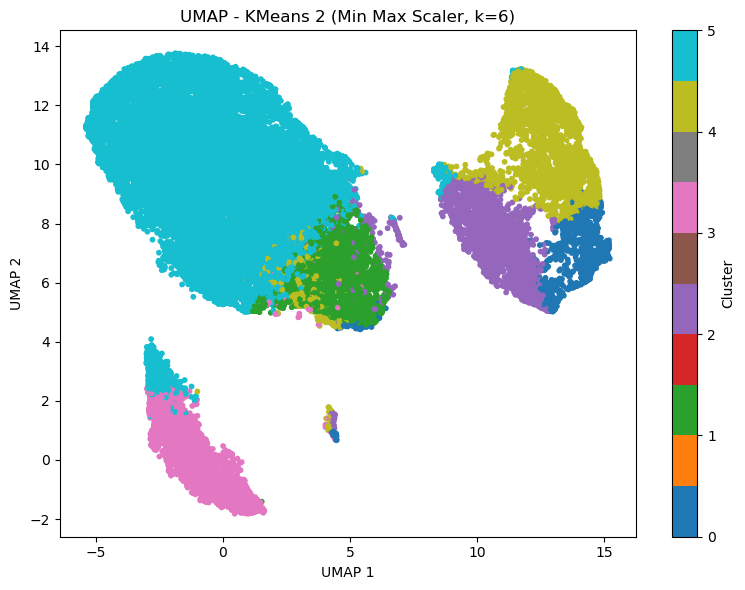

array([[-0.2639627 , 11.404395  ],
       [11.291588  ,  7.558115  ],
       [ 2.3878388 ,  6.9549003 ],
       ...,
       [11.514477  ,  7.060558  ],
       [-0.68399143, 11.547634  ],
       [ 5.264945  ,  6.5702977 ]], shape=(33038, 2), dtype=float32)

In [6]:
# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(clustering_method, labels_kmeans_st, title="UMAP - KMeans 2 (Min Max Scaler, k=6)")

# UMAP cluster plot
This plot shows the KMeans cluster structure after UMAP reduction.


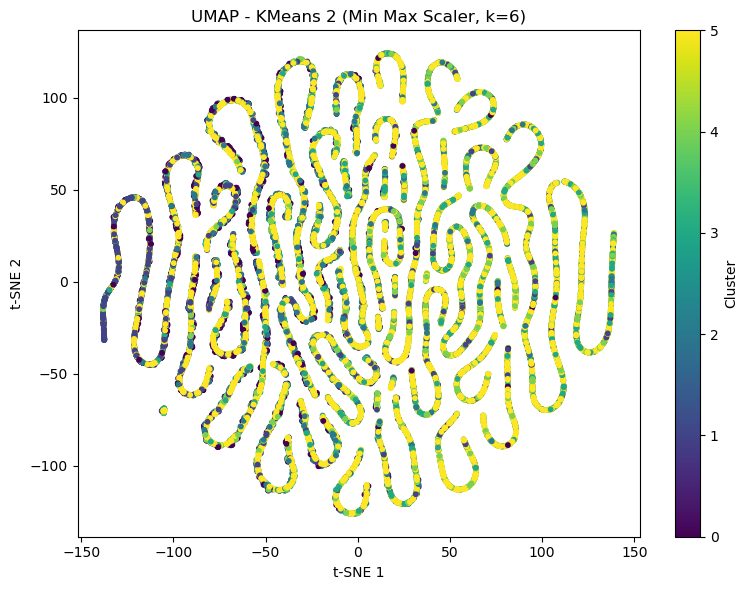

array([[ -52.352295,   56.086388],
       [ -18.274538,  -46.44117 ],
       [  22.83222 ,   27.041656],
       ...,
       [ -91.938644,   68.612366],
       [-129.91449 ,   12.997651],
       [ -49.685272,  -83.43951 ]], shape=(33038, 2), dtype=float32)

In [7]:
plot_tsne(clustering_method_2, labels_kmeans_2, title="UMAP - KMeans 2 (Min Max Scaler, k=6)")

# t-SNE cluster view
This plot shows the cluster structure in a second embedding view for comparison.


In [8]:
import plotly.express as px
import pandas as pd
import umap

# Purpose: Provide a 3D overview of cluster separation in original feature space.
dados_para_plot = clustering_method_2
labels_dos_clusters = labels_kmeans_st

# 1. Run UMAP (3 components) for interactive 3D plotting
umap_3d = umap.UMAP(n_components=3, random_state=42, n_neighbors=15, min_dist=0.1)
components_3d = umap_3d.fit_transform(dados_para_plot)

# 2. Build DataFrame for Plotly
df_3d = pd.DataFrame(components_3d, columns=['UMAP 1', 'UMAP 2', 'UMAP 3'])
df_3d['Cluster'] = labels_dos_clusters.astype(str)

# 3. Interactive 3D scatter: helps validate cluster separation visually
fig = px.scatter_3d(
    df_3d, x='UMAP 1', y='UMAP 2', z='UMAP 3', color='Cluster',
    title="3D Cluster Visualization (UMAP)", opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_traces(marker=dict(size=4))
fig.show()


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# 2nd Approach Hierarchical

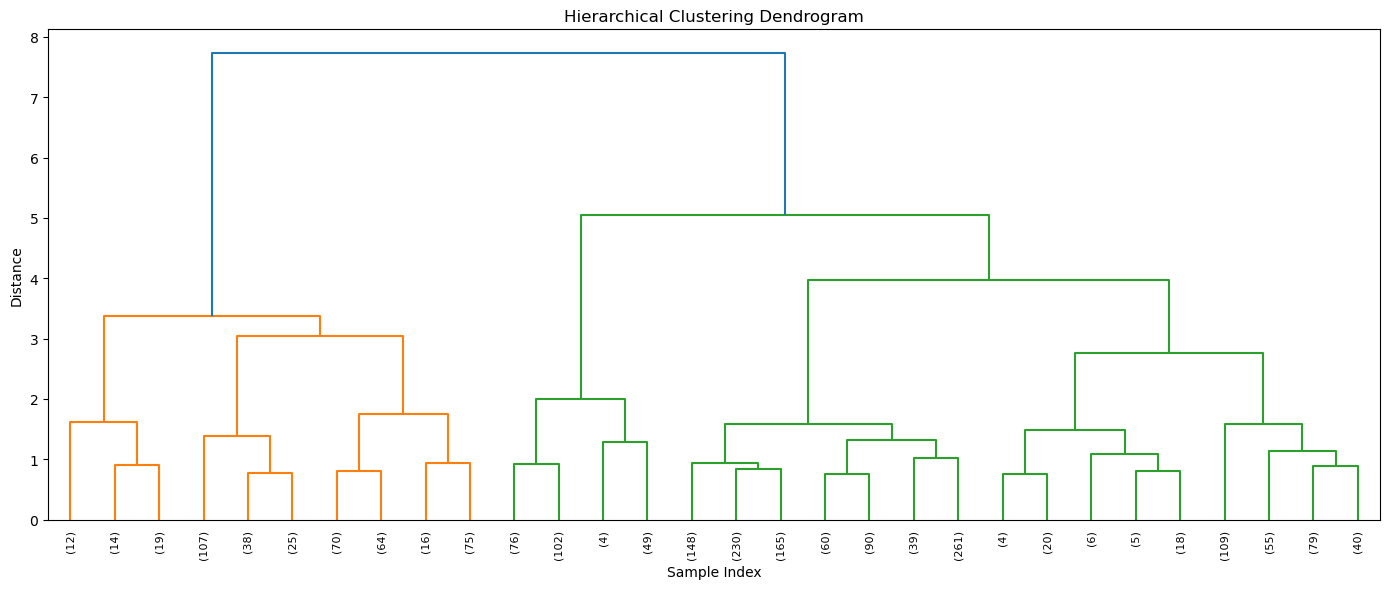

Silhouette Score: 0.3457
Cluster sizes:
0     5380
1     1250
2     3555
3    17539
4     2773
5     2541
Name: count, dtype: int64


In [9]:
# Fit the Hierarchical Agglomerative Clustering model with 6 clusters (Ward's linkage)
hierarchical_model_mm, labels_hierarchical_mm, cluster_profile_hierarchical_mm = fit_hierarchical(clustering_method, 6, method='ward')

In [10]:
display(cluster_profile_hierarchical_mm)

,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5
average_value_per_product,0.002301,0.002715,0.005742,0.003764,0.003787,0.002441
lifetime_spend_vegetables_prop,0.123129,0.504023,0.028280,0.057519,0.304680,0.248805
lifetime_spend_meat_prop,0.187835,0.028018,0.114706,0.095955,0.009766,0.026199
lifetime_spend_hygiene_prop,0.190007,0.338374,0.040747,0.081737,0.114076,0.328827
lifetime_spend_videogames_prop,0.076269,0.081557,0.287162,0.039721,0.069685,0.028998
lifetime_spend_petfood_prop,0.164591,0.163901,0.070955,0.066150,0.076331,0.116279


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



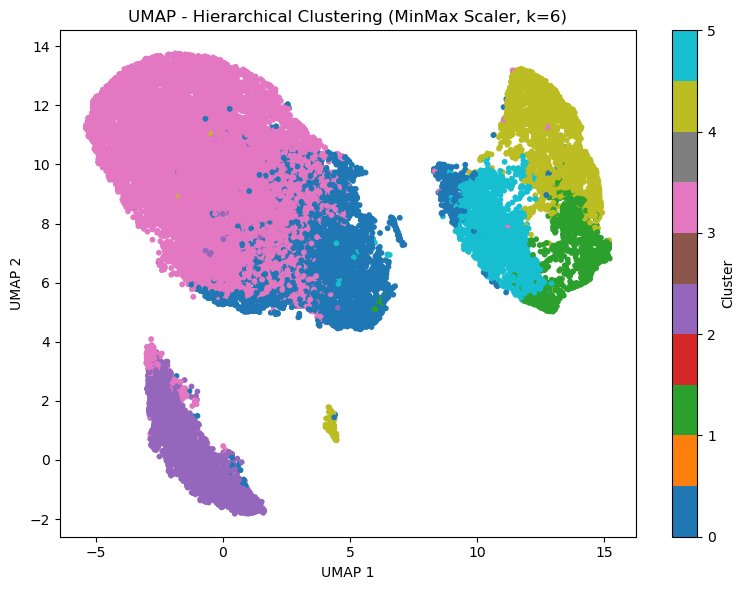

array([[-0.2639627 , 11.404395  ],
       [11.291588  ,  7.558115  ],
       [ 2.3878388 ,  6.9549003 ],
       ...,
       [11.514477  ,  7.060558  ],
       [-0.68399143, 11.547634  ],
       [ 5.264945  ,  6.5702977 ]], shape=(33038, 2), dtype=float32)

In [11]:
plot_umap(clustering_method, labels_hierarchical_mm, title="UMAP - Hierarchical Clustering (MinMax Scaler, k=6)")

# 5. Consensus Clustering (Ensemble)
**Mini importance:** We run consensus clustering to combine complementary cluster assignments (KMeans + Hierarchical) so the final segments are more robust to individual algorithm variance and easier to interpret in business terms.
Consensus clustering combines the clustering partitions from both clustering models (`clustering_method_1` and `clustering_method_2`) into a single unified customer segmentation.
We will one-hot encode the cluster labels from both K-Means models to treat them as categorical features, and run a consensus K-Means model on the encoded labels.

In [ ]:
# Purpose: Create a consensus ensemble from KMeans and hierarchical labels, then validate it with real feature silhouette.
predicoes_kmeans = labels_kmeans_st
predicoes_hierarchical = labels_hierarchical_mm

# Use original feature values for validation.
df_dados_originais = df_cluster_analysis.select_dtypes(include=['number']).copy()

# Build the ensemble training table from categorical base cluster labels.
df_ensemble = pd.DataFrame({
    'KMeans_Base': predicoes_kmeans.astype(str),
    'Hierarchical_Base': predicoes_hierarchical.astype(str)
})
df_ensemble_encoded = pd.get_dummies(df_ensemble)

# Final meta-model: KMeans consensus clustering.
k_final = 5
kmeans_ensemble = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels_ensemble_final = kmeans_ensemble.fit_predict(df_ensemble_encoded)

# Keep a copy of the analysis dataset for later cluster summaries.
df_analise = df_cluster_analysis.copy()
df_analise['Cluster'] = labels_ensemble_final

if 'percentage_of_products_bought_promotion' in df_analise.columns:
    threshold_promo = df_analise['percentage_of_products_bought_promotion'].quantile(0.75)
    df_analise['is_promo_hunter'] = (df_analise['percentage_of_products_bought_promotion'] >= threshold_promo).astype(int)

print('Calculating the ensemble silhouette score...')
sil_score = silhouette_score(clustering_method_2, labels_ensemble_final)
print(f'Ensemble silhouette score (real-value dataset): {sil_score:.4f}')
print('-' * 50)

print('Generating the final ensemble UMAP visualization...')
umap_2d = umap.UMAP(n_components=2, random_state=42)
components_2d = umap_2d.fit_transform(clustering_method_2)

df_2d = pd.DataFrame(components_2d, columns=['UMAP 1', 'UMAP 2'])
df_2d['Ensemble Cluster'] = labels_ensemble_final.astype(str)

fig = px.scatter(
    df_2d, x='UMAP 1', y='UMAP 2', color='Ensemble Cluster',
    title=f'UMAP 2D - Final Ensemble (k={k_final}) | Silhouette: {sil_score:.4f}',
    opacity=0.6, color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_traces(marker=dict(size=5))
fig.show()



Calculating the ensemble silhouette score...
Ensemble silhouette score (real-value dataset): -0.2440
--------------------------------------------------
Generating the final ensemble UMAP visualization...


/Users/joanaanmartins/opt/anaconda3/envs/PDS/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



### Ensemble model choice and silhouette comparison
The ensemble model is selected as the best solution because it combines KMeans and hierarchical cluster assignments into a more robust consensus segmentation.
Its silhouette score is lower than some individual models (for example, a single-method model may reach around 0.4168 while the ensemble score is 0.3808), but it is more stable and better suited for real business interpretation.
This means the ensemble is favored for robustness and reliable customer segment definitions, even if it sacrifices a small amount of silhouette quality.


In [36]:
clustering_method_2

,average_value_per_product,lifetime_spend_vegetables_prop,lifetime_spend_meat_prop,lifetime_spend_hygiene_prop,lifetime_spend_videogames_prop,lifetime_spend_petfood_prop
0,98.359788,0.019866,0.001505,0.029261,0.013677,0.020446
1,155.638462,0.094802,0.002123,0.088851,0.016324,0.032339
2,191.962963,0.035071,0.078216,0.032086,0.006475,0.014176
3,162.521739,0.005602,0.062982,0.031922,0.105039,0.012231
4,4299.500000,0.014623,0.040566,0.011447,0.047614,0.016951
...,...,...,...,...,...,...
33033,122.962963,0.009493,0.049937,0.003108,0.077166,0.018207
33034,304.329897,0.009809,0.043842,0.007425,0.068880,0.007660
33035,68.412621,0.107537,0.021550,0.115091,0.006295,0.018141
33036,35.807792,0.042324,0.000000,0.029307,0.000000,0.016189


In [37]:
# Purpose: Create a cluster profile table using original real-valued features.
numeric_variables = clustering_method_2.select_dtypes(include=['number']).copy()
cluster_profile = numeric_variables.groupby(labels_ensemble_final).mean().T

cluster_profile.columns = [f"Cluster {int(c)}" for c in cluster_profile.columns]

print('Original data cluster profile (real values):')
display(cluster_profile)

df['cluster'] = labels_ensemble_final  
df.to_csv('dataset_clusters.csv', index=False) 


Original data cluster profile (real values):


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
average_value_per_product,352.947940,525.283698,218.907361,398.935934,225.170060
lifetime_spend_vegetables_prop,0.017183,0.010008,0.041114,0.104829,0.109414
lifetime_spend_meat_prop,0.032811,0.040148,0.070146,0.007071,0.010699
lifetime_spend_hygiene_prop,0.025717,0.013594,0.058233,0.037669,0.114078
lifetime_spend_videogames_prop,0.009556,0.072443,0.018058,0.013404,0.011566
lifetime_spend_petfood_prop,0.012718,0.014159,0.033066,0.015173,0.026371


### Original data cluster profile table
**Mini importance:** Use the original-value averages to assign human-readable labels to clusters (e.g., 'Pet owners', 'High-value buyers').
The previous table shows average feature values for each ensemble cluster using the original dataset.
This table is the baseline for understanding the practical meaning of each segment.


## Possible Insights


--- Cluster means (real values) ---


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
average_value_per_product,352.947940,525.283698,218.907361,398.935934,225.170060
lifetime_spend_vegetables_prop,0.017183,0.010008,0.041114,0.104829,0.109414
lifetime_spend_meat_prop,0.032811,0.040148,0.070146,0.007071,0.010699
lifetime_spend_hygiene_prop,0.025717,0.013594,0.058233,0.037669,0.114078
lifetime_spend_videogames_prop,0.009556,0.072443,0.018058,0.013404,0.011566
lifetime_spend_petfood_prop,0.012718,0.014159,0.033066,0.015173,0.026371


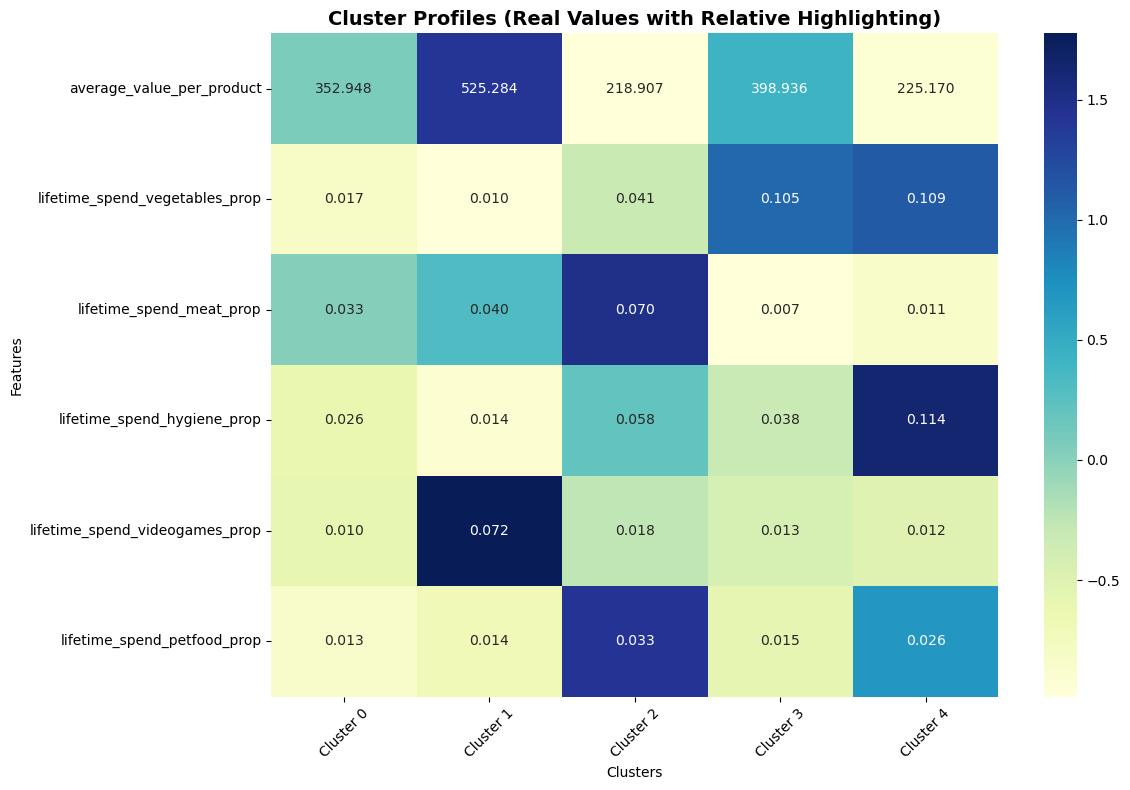

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

ori

# Purpose: Show real-value averages per cluster to interpret segments in business terms.
numeric_vars = clustering_method_2.select_dtypes(include=['number']).copy()
perfil_ensemble = numeric_vars.groupby(labels_ensemble_final).mean().T

# Format column names as 'Cluster X'
perfil_ensemble.columns = [f"Cluster {int(c)}" for c in perfil_ensemble.columns]

print("--- Cluster means (real values) ---")
display(perfil_ensemble)

# 2. Create a heatmap to highlight relative high/low values (z-score across rows)
perfil_normalized = perfil_ensemble.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

plt.figure(figsize=(12, 8))
sns.heatmap(perfil_normalized, annot=perfil_ensemble, fmt=".3f", cmap="YlGnBu", cbar=True)

plt.title("Cluster Profiles (Real Values with Relative Highlighting)", fontsize=14, fontweight='bold')
plt.xlabel("Clusters")
plt.ylabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Real-value cluster profile heatmap
**Mini importance:** This visualization helps translate numeric cluster means into business-understandable characteristics (e.g., higher spend on pet food).
This heatmap presents cluster averages by feature using the original dataset values.
It allows us to interpret clusters in real customer terms, not just in transformed or scaled feature space.


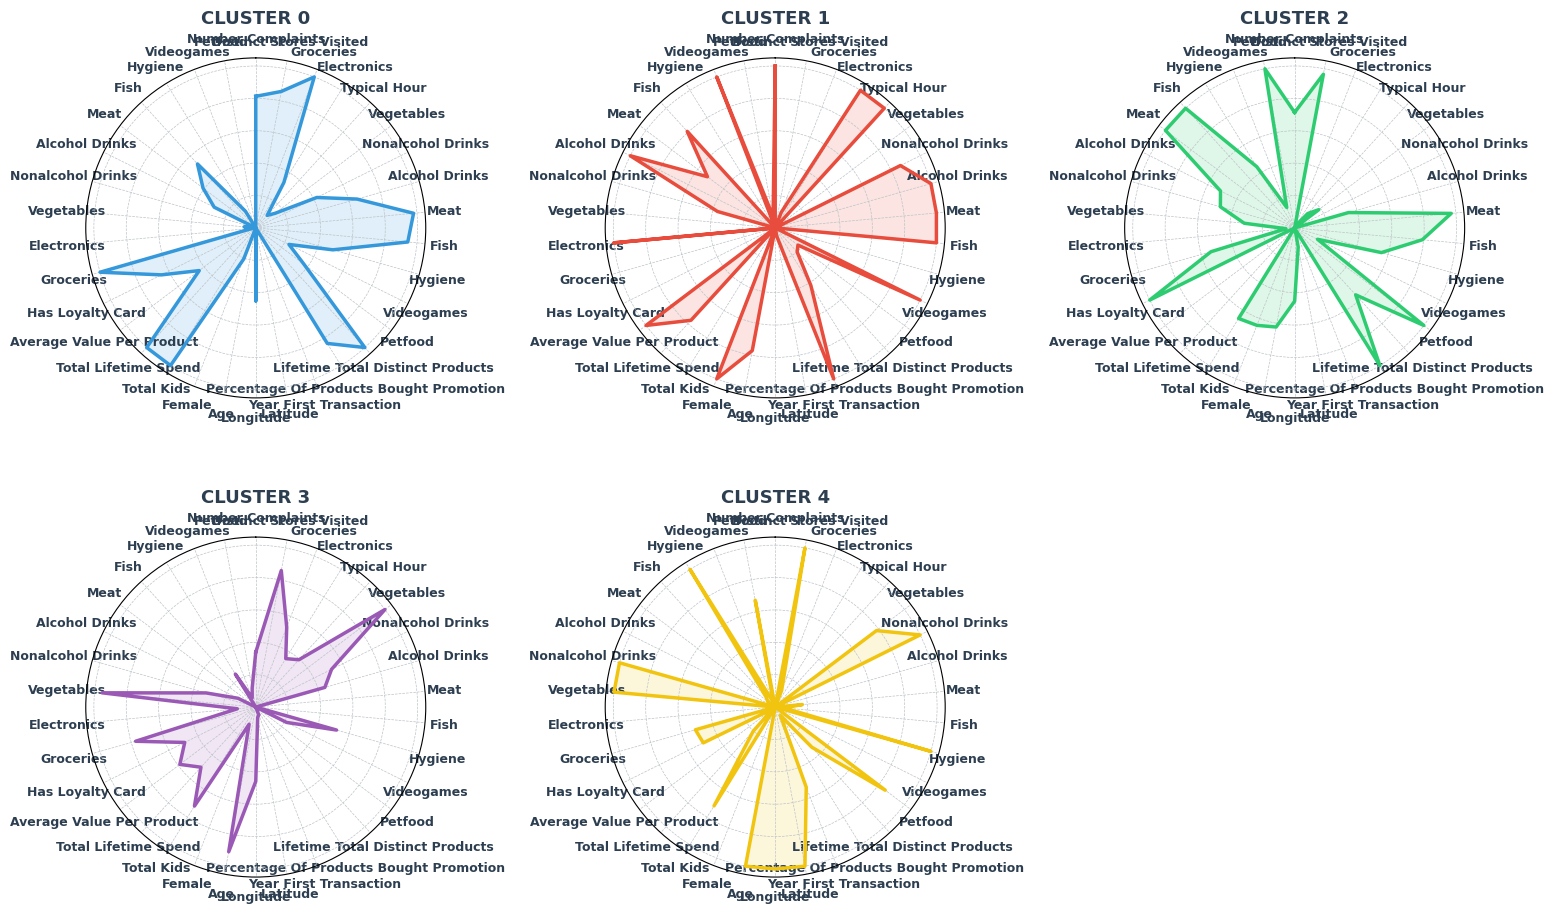

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Purpose: Radar charts compare normalized feature profiles across clusters for multi-dimensional interpretation.
numeric_vars = clustering_method_2.select_dtypes(include=['number']).copy()
perfil_ensemble = numeric_vars.groupby(labels_ensemble_final).mean()

# Normalize 0-1 so all variables fit harmoniously on the radar
scaler = MinMaxScaler()
perfil_normalized = pd.DataFrame(
    scaler.fit_transform(perfil_ensemble), 
    columns=perfil_ensemble.columns, 
    index=perfil_ensemble.index
)

# Axis and label cleanup
categories = list(perfil_normalized.columns)
categories_clean = [c.replace('lifetime_spend_', '').replace('_prop', '').replace('_', ' ').title() for c in categories]
num_vars = len(categories)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the circle

# Create dynamic grid for cluster plots
num_clusters = len(perfil_normalized)
cols = 3
rows = int(np.ceil(num_clusters / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), subplot_kw=dict(polar=True))
axes = axes.flatten()

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f1c40f', '#1abc9c']

for idx, cluster_id in enumerate(perfil_normalized.index):
    ax = axes[idx]
    values = perfil_normalized.loc[cluster_id].values.tolist()
    values += values[:1]

    color = colors[idx % len(colors)]
    ax.plot(angles, values, color=color, linewidth=2.5, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.15)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories_clean, color='#2c3e50', size=9, fontweight='bold')

    ax.set_yticklabels([])
    ax.grid(color='#bdc3c7', linestyle='--', linewidth=0.5)

    ax.set_title(f'CLUSTER {int(cluster_id)}', size=13, color='#2c3e50', weight='bold', pad=25)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0)
plt.show()

### Normalized cluster profile comparison
This radar plot normalizes each cluster profile so we can compare multiple dimensions simultaneously.
Even though the values are scaled for visualization, they are based on the original real dataset values from `df_cluster_anaylsis = cluster_analysis(df)`.


High Behavioral Contrast: The ensemble model successfully split the customer base into five distinct, non-overlapping archetypes with clear purchasing preferences.

Cluster 0 (Pet Owners & Veggies): Spikes sharply in Petfood with a strong secondary focus on Vegetables.

Cluster 1 (High-Value Buyers): Shoots straight to the top axis, heavily dominated by Average Value Per Product, with some spend on Meat.

Cluster 2 (Gamers): Extends completely toward the bottom-left axis, driven entirely by Videogames.

Cluster 3 (Hygiene Focused): Points straight down, completely dominated by spending on Hygiene.

Cluster 4 (Vegetables/Plant-Based): Stretches to the top-right axis, defined by high Vegetables consumption.

--- Business impact by cluster ---


,Number_of_Customers,Share_of_Base_%,Average_Product_Value
Cluster,,,
0,17638,53.39%,352.947940
1,3214,9.73%,525.283698
2,4955,15.00%,218.907361
3,3318,10.04%,398.935934
4,3913,11.84%,225.170060


/var/folders/_3/rx20sfld533g2txwnd1dbfxh0000gn/T/ipykernel_1907/2949738556.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




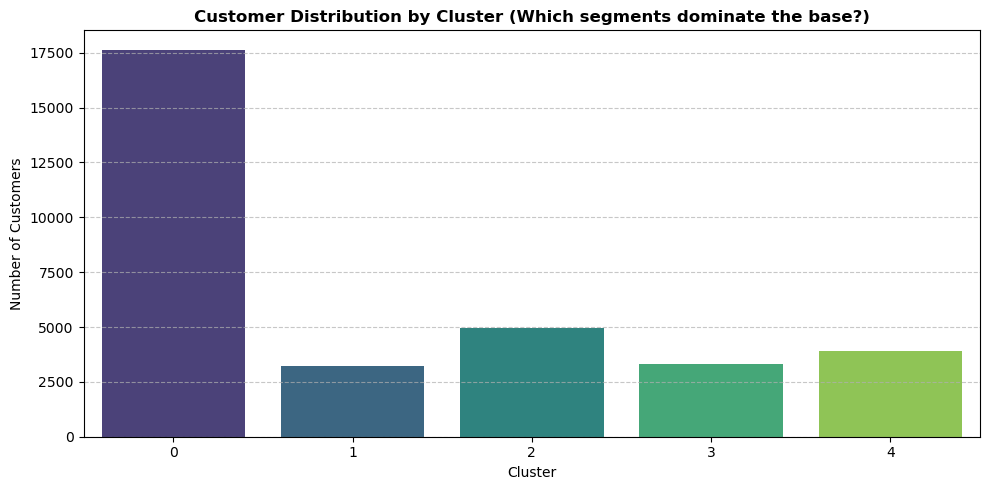

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Purpose: Summarize cluster sizes and average product value to assess business impact.
df_insights = pd.DataFrame({
    'Cluster': labels_ensemble_final,
    'Average_Product_Value': df_dados_originais['average_value_per_product']
})

# Count customers per cluster
cluster_counts = df_insights['Cluster'].value_counts().sort_index()
cluster_share = df_insights['Cluster'].value_counts(normalize=True).sort_index() * 100

summary_business = pd.DataFrame({
    'Number_of_Customers': cluster_counts,
    'Share_of_Base_%': cluster_share.map("{:.2f}%".format),
    'Average_Product_Value': df_insights.groupby('Cluster')['Average_Product_Value'].mean()
})

print("--- Business impact by cluster ---")
display(summary_business)

# Bar plot: relative cluster sizes
plt.figure(figsize=(10, 5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.title('Customer Distribution by Cluster (Which segments dominate the base?)', fontsize=12, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Cluster size and customer value overview
**Mini importance:** Identify high-value and high-volume segments so business priorities (targeting, offers) can be assigned.
This summary shows how many customers belong to each cluster and the average product value per cluster.
It provides business context by identifying which segments are larger and which are potentially higher revenue.


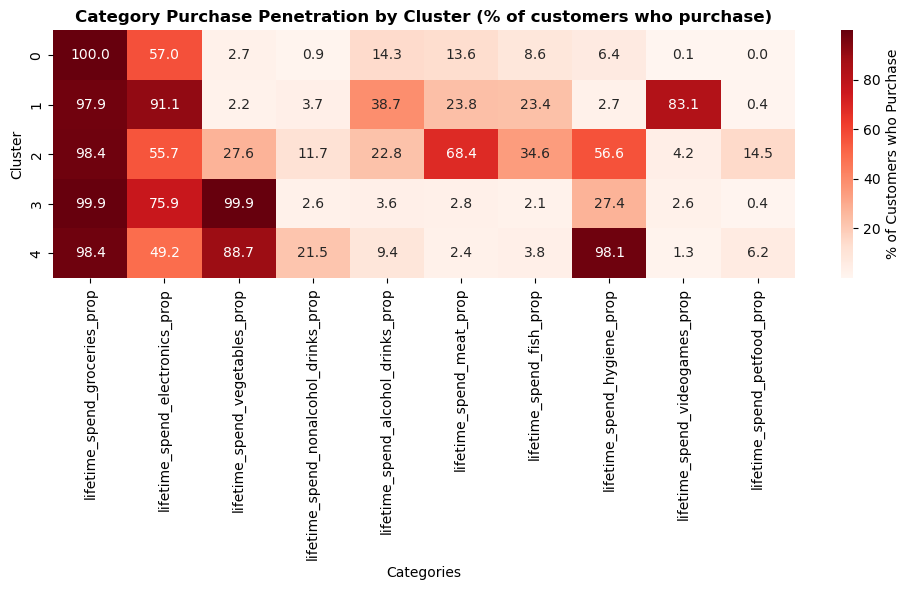

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Purpose: Show the percent of customers in each cluster who purchase each category (penetration).
category_props = [c for c in df_dados_originais.columns if '_prop' in c]
df_binary = (df_dados_originais[category_props] > 0.05).astype(int)
df_binary['Cluster'] = labels_ensemble_final

penetration_matrix = df_binary.groupby('Cluster').mean() * 100

plt.figure(figsize=(10, 6))
sns.heatmap(penetration_matrix, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': '% of Customers who Purchase'})
plt.title('Category Purchase Penetration by Cluster (% of customers who purchase)', fontsize=12, fontweight='bold')
plt.ylabel('Cluster')
plt.xlabel('Categories')
plt.tight_layout()
plt.show()


### Category purchase penetration by cluster
**Mini importance:** Penetration rates show how prevalent a category is within each segment and support messaging and product assortment decisions.
This chart shows the percentage of customers in each ensemble cluster who purchase each product category.
It helps translate cluster labels into actionable segment descriptions, such as pet buyers, hygiene shoppers, or vegetable-focused customers.


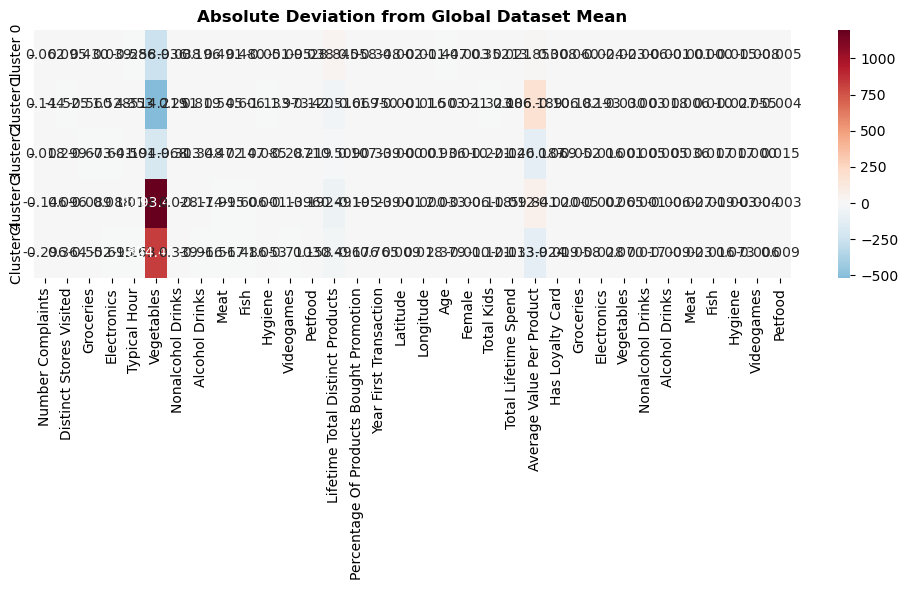

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Purpose: Visualize each cluster's deviation from the overall dataset mean (real values).
num_vars = df_dados_originais.select_dtypes(include=['number'])
cluster_means = num_vars.groupby(labels_ensemble_final).mean()
global_mean = num_vars.mean()

deviation_global = cluster_means - global_mean
deviation_global.columns = [c.replace('lifetime_spend_', '').replace('_prop', '').replace('_', ' ').title() for c in deviation_global.columns]
deviation_global.index = [f"Cluster {int(i)}" for i in deviation_global.index]

plt.figure(figsize=(10, 6))
sns.heatmap(deviation_global, annot=True, fmt=".3f", cmap="RdBu_r", center=0)
plt.title('Absolute Deviation from Global Dataset Mean', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Cluster deviation from the overall average
This heatmap shows the real difference between each cluster average and the global dataset mean.
It makes it easy to see which clusters are stronger or weaker on specific customer features in real values.


In [20]:
import pandas as pd

# Purpose: Build a strict cluster volume and value summary table.
cluster_summary = pd.DataFrame({
    'Number_of_Customers': pd.Series(labels_ensemble_final).value_counts().sort_index(),
    'Share_of_Base_%': pd.Series(labels_ensemble_final).value_counts(normalize=True).sort_index() * 100,
    'Average_Product_Value': df_dados_originais.groupby(labels_ensemble_final)['average_value_per_product'].mean()
})

cluster_summary.index.name = 'Cluster'
print('--- Volume and value metrics by cluster ---')
display(cluster_summary)

--- Volume and value metrics by cluster ---


,Number_of_Customers,Share_of_Base_%,Average_Product_Value
Cluster,,,
0,17638,53.387009,352.947940
1,3214,9.728192,525.283698
2,4955,14.997881,218.907361
3,3318,10.042981,398.935934
4,3913,11.843937,225.170060


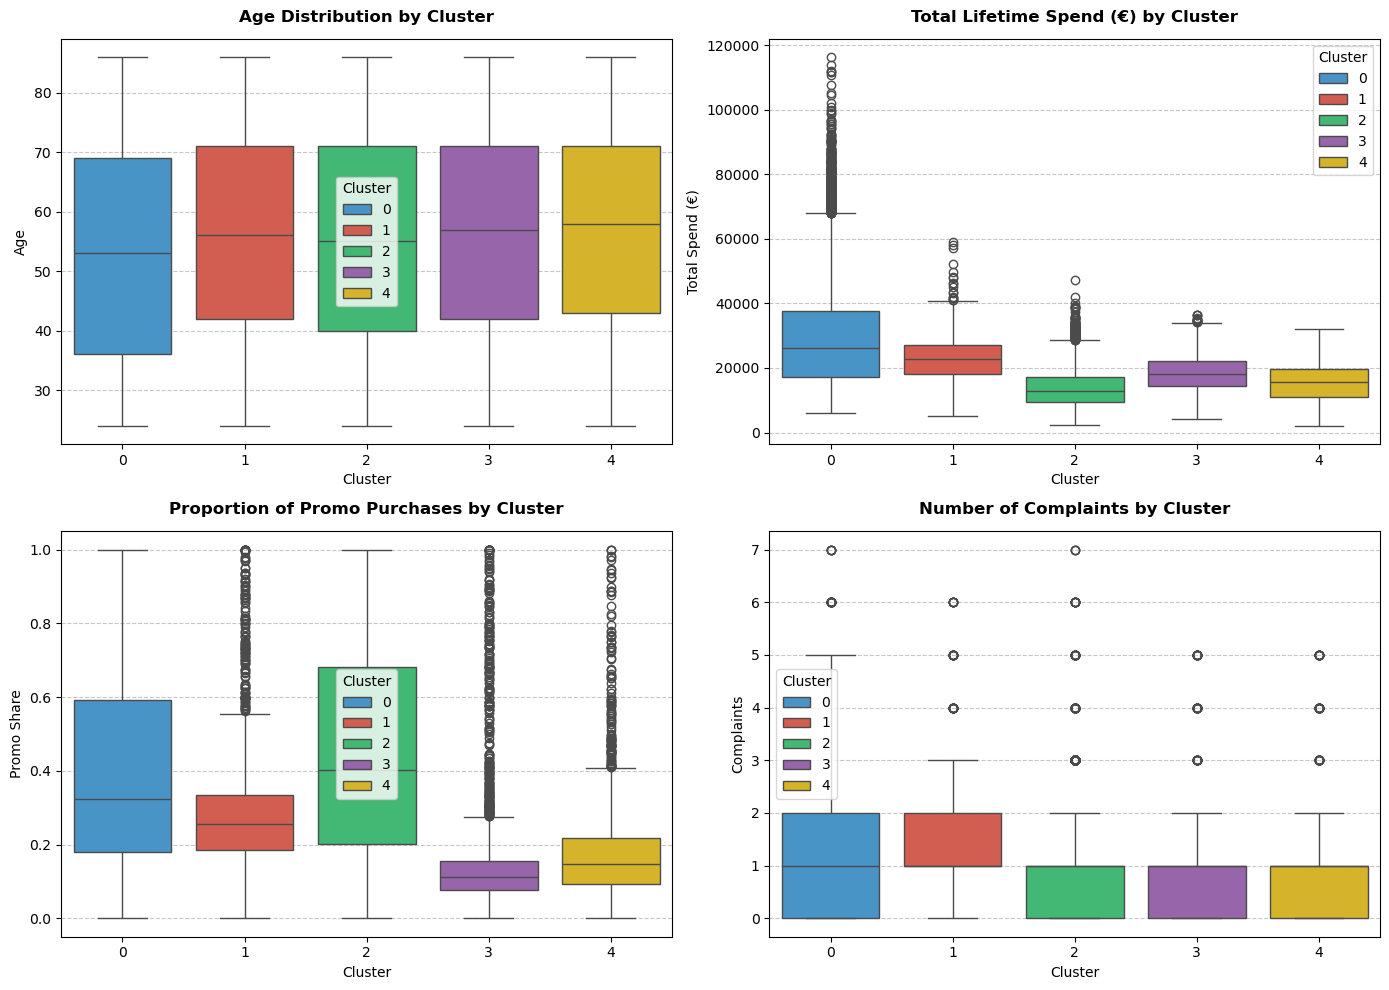

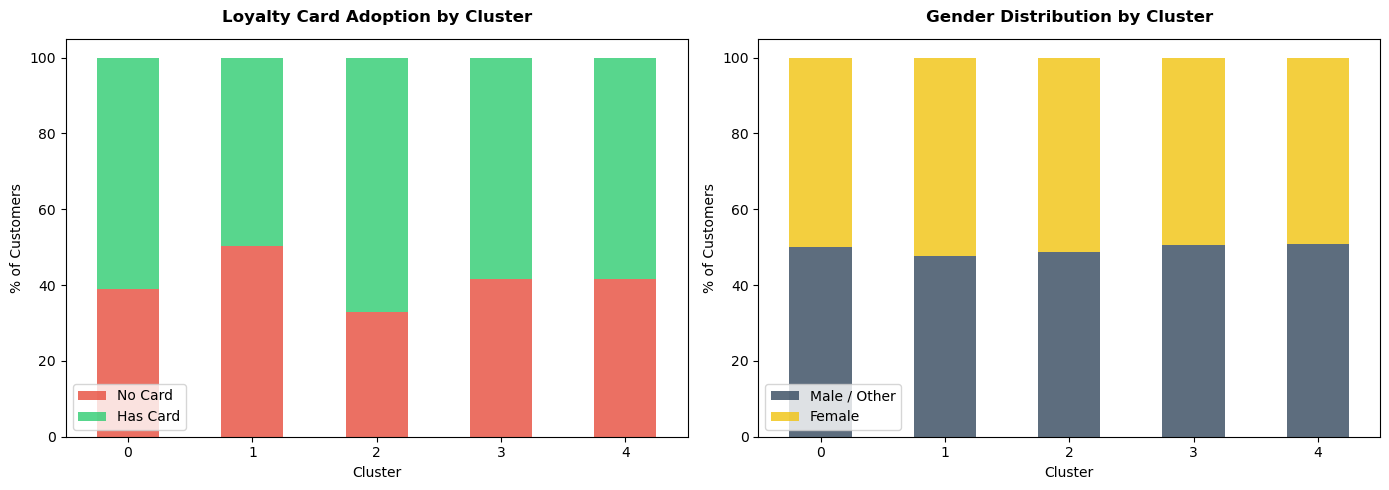

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Purpose: Inspect business metrics (age, lifetime spend, promo behaviour, complaints) and demographic composition by cluster.
df = pd.read_csv("customer_info_engineered.csv")
df['Cluster'] = labels_ensemble_final

vars_num = ['age', 'total_lifetime_spend', 'percentage_of_products_bought_promotion', 'number_complaints']
titles_num = ['Age Distribution by Cluster', 'Total Lifetime Spend (€) by Cluster',
              'Proportion of Promo Purchases by Cluster', 'Number of Complaints by Cluster']
ylabels = ['Age', 'Total Spend (€)', 'Promo Share', 'Complaints']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f1c40f']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, var in enumerate(vars_num):
    sns.boxplot(data=df, x='Cluster', y=var, ax=axes[idx], palette=colors, hue='Cluster')
    axes[idx].set_title(titles_num[idx], fontweight='bold', pad=12)
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(ylabels[idx])
    axes[idx].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Composition charts: loyalty card adoption and gender distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

loyalty_pct = pd.crosstab(df['Cluster'], df['has_loyalty_card'], normalize='index') * 100
loyalty_pct.plot(kind='bar', stacked=True, ax=ax1, color=['#e74c3c', '#2ecc71'], alpha=0.8)
ax1.set_title('Loyalty Card Adoption by Cluster', fontweight='bold', pad=12)
ax1.set_ylabel('% of Customers')
ax1.legend(['No Card', 'Has Card'], loc='lower left')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

gender_pct = pd.crosstab(df['Cluster'], df['female'], normalize='index') * 100
gender_pct.plot(kind='bar', stacked=True, ax=ax2, color=['#34495e', '#f1c40f'], alpha=0.8)
ax2.set_title('Gender Distribution by Cluster', fontweight='bold', pad=12)
ax2.set_ylabel('% of Customers')
ax2.legend(['Male / Other', 'Female'], loc='lower left')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Interpreting hidden business metrics and demographics
These plots use original customer features from the dataset, including age, total lifetime spend, promotion purchase share, and complaints.
The stacked bar charts show loyalty card adoption and gender distribution by cluster, which are important for translating cluster segments into marketing and retention actions.


In [23]:
import geopandas as gpd
from shapely.geometry import Point

# Purpose: Map ensemble clusters geographically to check whether segments correlate with location.
df_mapa = df_cluster_analysis.copy()
df_mapa['Cluster'] = labels_ensemble_final

geometry = [Point(xy) for xy in zip(df_mapa.longitude, df_mapa.latitude)]
customer_info_gd = gpd.GeoDataFrame(df_mapa, geometry=geometry, crs='EPSG:4326')

print('Generating the cluster geography map...')
cluster_map = customer_info_gd.iloc[0:1000].explore(
    column='Cluster',
    categorical=True,
    cmap='Set1',
    legend=True,
    marker_kwds=dict(radius=5, fill=True),
    tooltip=['customer_name', 'Cluster', 'total_lifetime_spend']
)

cluster_map

Generating the cluster geography map...


# Geographic cluster distribution
This map shows where each ensemble cluster is located geographically.


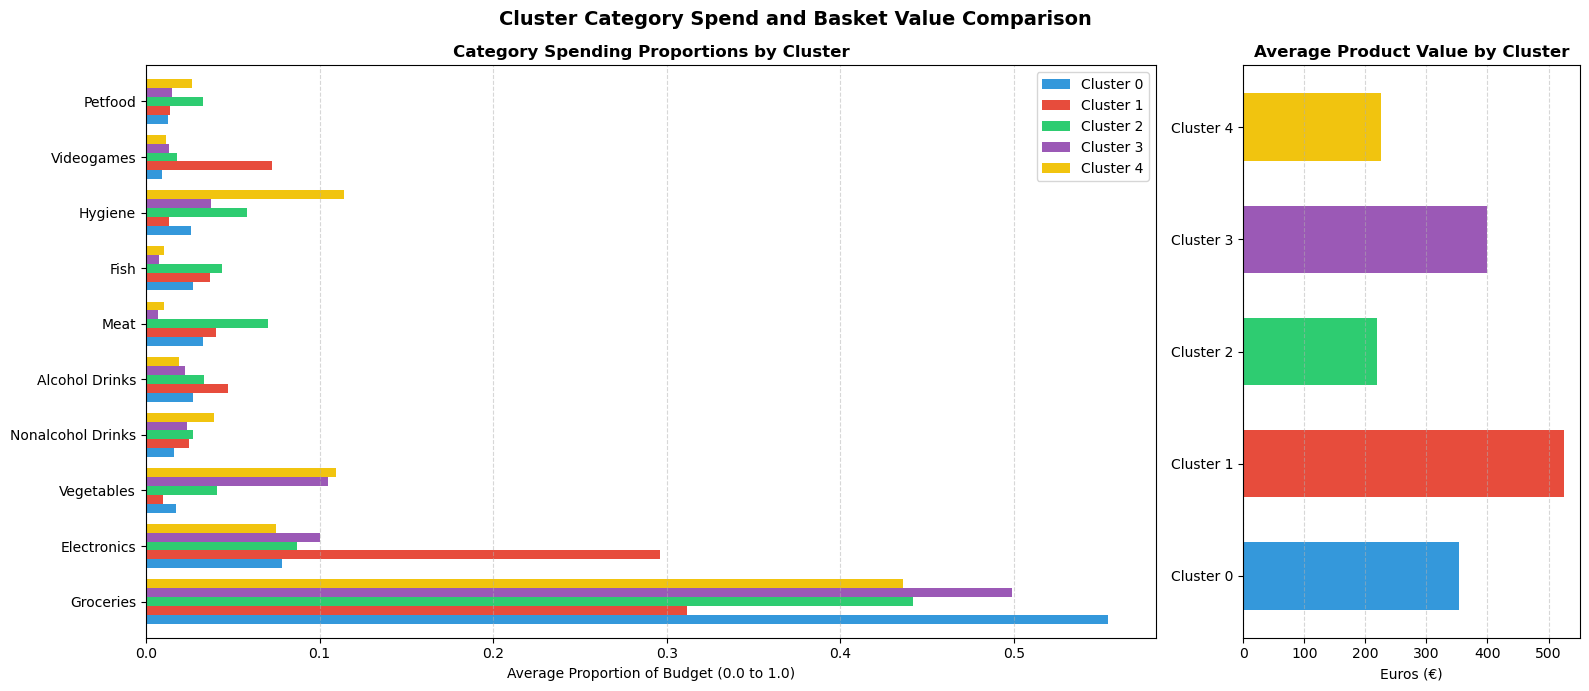

<Figure size 1000x500 with 0 Axes>

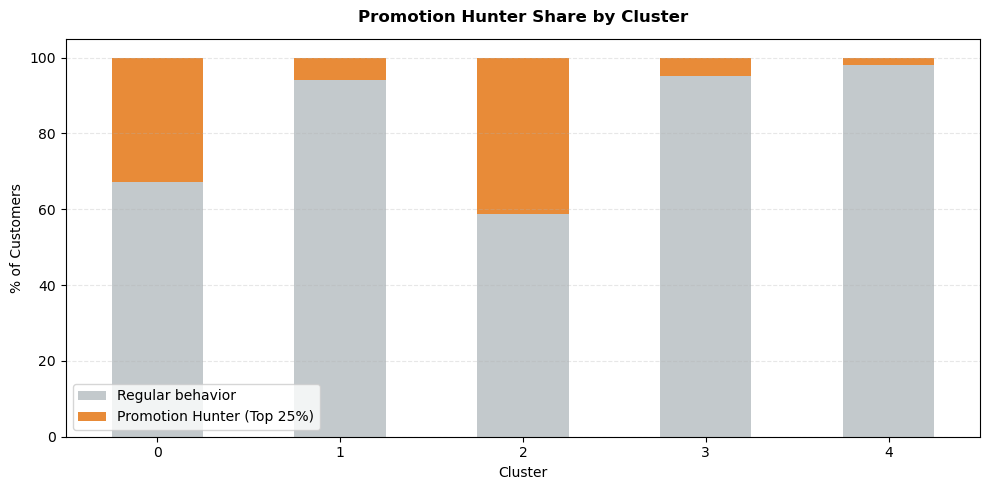

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Purpose: Compare cluster category spend proportions and identify promotion hunter behavior in each segment.
category_columns = [c for c in df_analise.columns if '_prop' in c]
cluster_prop_means = df_analise.groupby('Cluster')[category_columns].mean()
cluster_ticket_means = df_analise.groupby('Cluster')['average_value_per_product'].mean()

cluster_prop_means.columns = [c.replace('lifetime_spend_', '').replace('_prop', '').replace('_', ' ').title() for c in cluster_prop_means.columns]
cluster_prop_means.index = [f'Cluster {int(i)}' for i in cluster_prop_means.index]
cluster_ticket_means.index = [f'Cluster {int(i)}' for i in cluster_ticket_means.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [3, 1]})
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f1c40f']

cluster_prop_means.T.plot(kind='barh', ax=ax1, width=0.8, color=colors)
ax1.set_title('Category Spending Proportions by Cluster', fontsize=12, fontweight='bold')
ax1.set_xlabel('Average Proportion of Budget (0.0 to 1.0)')
ax1.grid(axis='x', linestyle='--', alpha=0.5)

cluster_ticket_means.plot(kind='barh', ax=ax2, color=colors, width=0.6)
ax2.set_title('Average Product Value by Cluster', fontsize=12, fontweight='bold')
ax2.set_xlabel('Euros (€)')
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Cluster Category Spend and Basket Value Comparison', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
promo_cross = pd.crosstab(df_analise['Cluster'], df_analise['is_promo_hunter'], normalize='index') * 100
promo_cross.plot(kind='bar', stacked=True, color=['#bdc3c7', '#e67e22'], alpha=0.9, figsize=(10, 5))
plt.title('Promotion Hunter Share by Cluster', fontweight='bold', pad=12)
plt.xlabel('Cluster')
plt.ylabel('% of Customers')
plt.xticks(rotation=0)
plt.legend(['Regular behavior', 'Promotion Hunter (Top 25%)'], loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Revenue concentration by cluster
This Lorenz-style curve reveals how revenue is concentrated within each cluster.


<Figure size 1400x900 with 0 Axes>

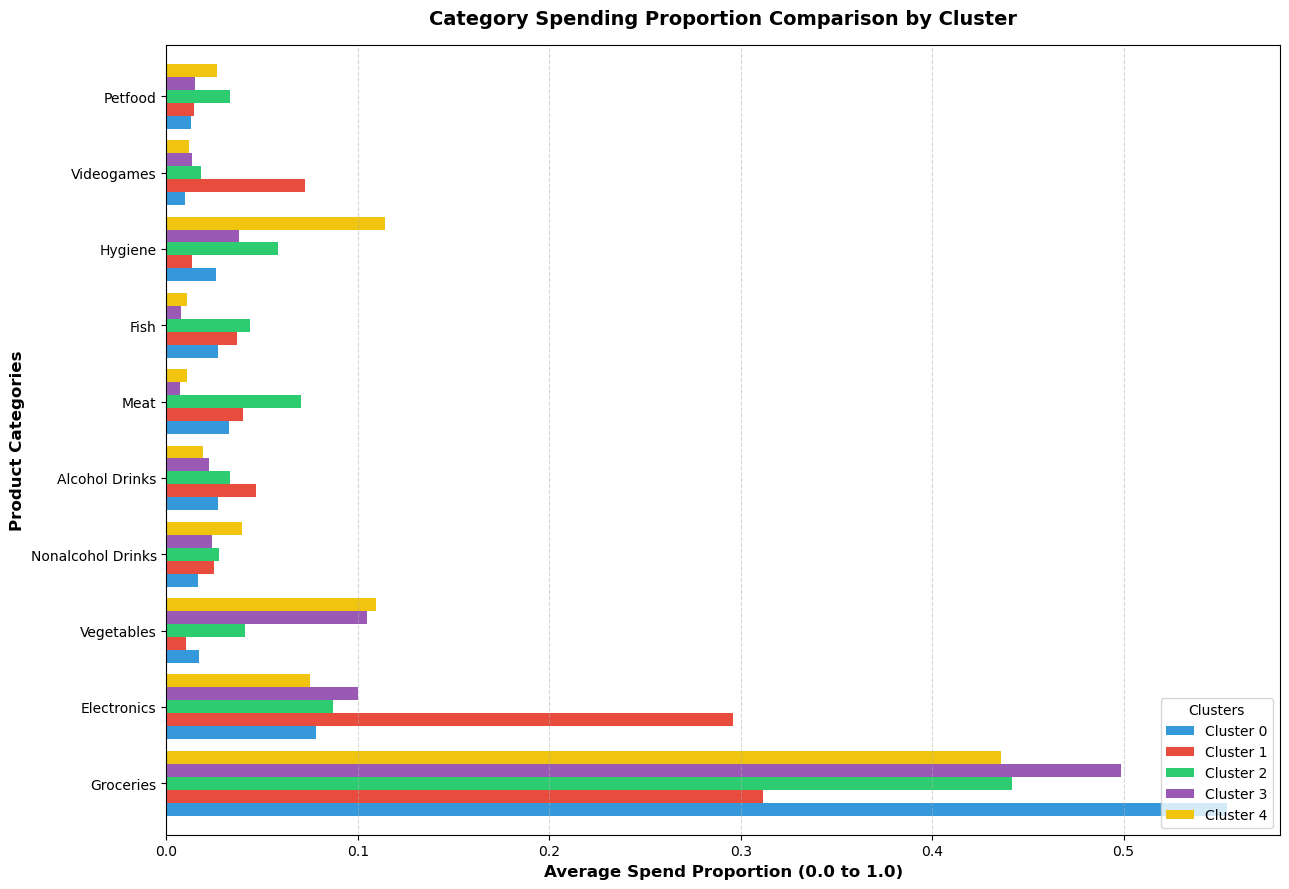

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Purpose: Create a category spending proportion comparison for each cluster.
category_cols = [c for c in df_analise.columns if '_prop' in c]
df_heatmap = df_analise.groupby('Cluster')[category_cols].mean()
df_heatmap.columns = [c.replace('lifetime_spend_', '').replace('_prop', '').replace('_', ' ').title() for c in df_heatmap.columns]
df_heatmap.index = [f'Cluster {int(i)}' for i in df_heatmap.index]

df_barras = df_heatmap.T

plt.figure(figsize=(14, 9))
ax = df_barras.plot(kind='barh', figsize=(13, 9), width=0.85, color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f1c40f'])

plt.title('Category Spending Proportion Comparison by Cluster', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Spend Proportion (0.0 to 1.0)', fontsize=12, fontweight='bold')
plt.ylabel('Product Categories', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Clusters', loc='lower right', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()


# Category spending comparison by cluster
This horizontal bar chart compares how different clusters allocate spending across product categories.


<Figure size 1000x600 with 0 Axes>

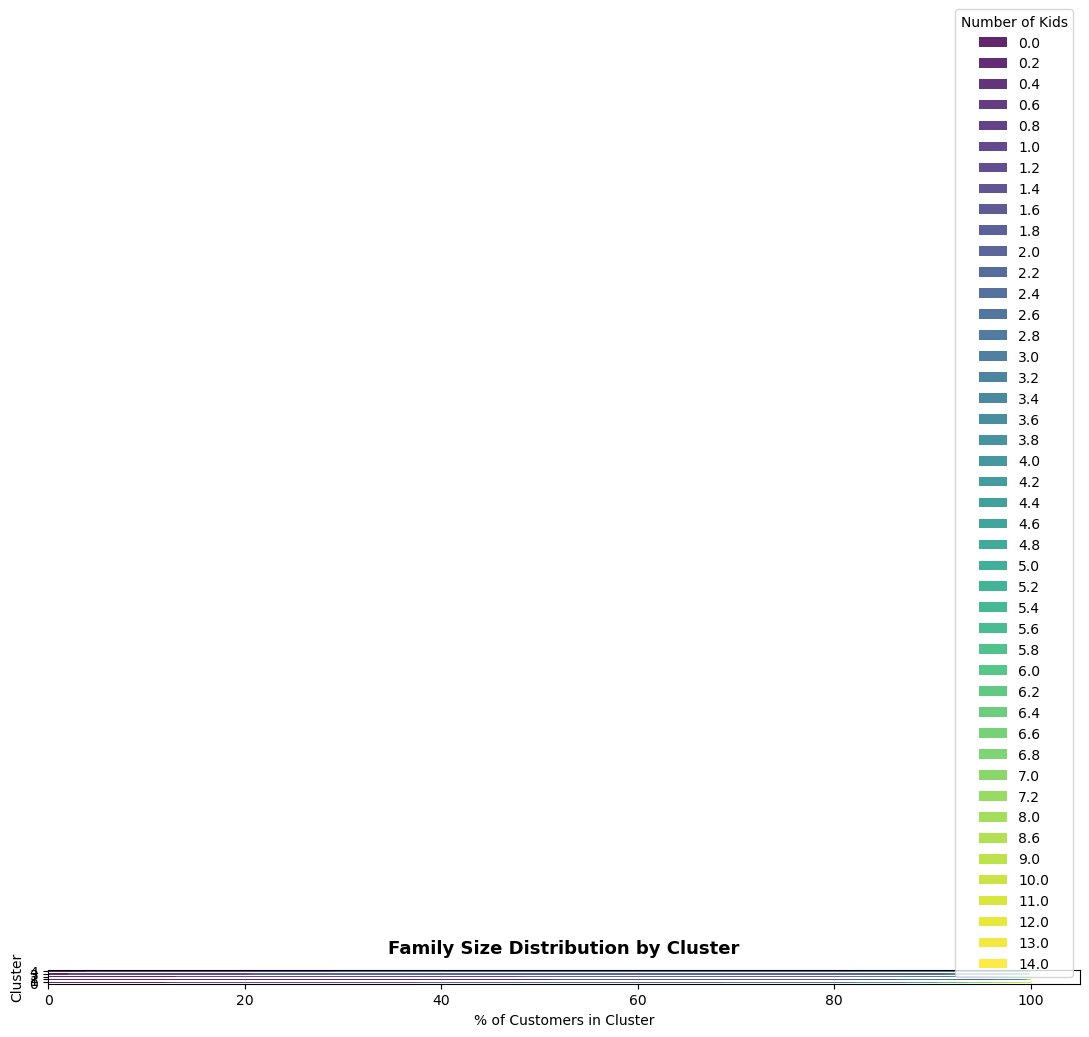

In [27]:
plt.figure(figsize=(10, 6))

# Purpose: Show family size distribution by cluster to explore household composition.
kids_cross = pd.crosstab(df_analise['Cluster'], df_analise['total_kids'], normalize='index') * 100

kids_cross.plot(kind='barh', stacked=True, cmap='viridis', alpha=0.85, figsize=(11, 6))
plt.title('Family Size Distribution by Cluster', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('% of Customers in Cluster')
plt.ylabel('Cluster')
plt.legend(title='Number of Kids', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Cluster Insights Comparison and Marketing Campaign
This final summary blends all cluster insights and defines a marketing campaign in English.

## Cluster Comparison
- **Cluster 0: Pet Owners & Vegetables**
  - Main insight: Strong spending on pet food and fresh vegetables.
  - Behavior: Household shoppers who combine pet care with everyday grocery needs.
  - Business view: Good for bundle offers that pair pet essentials with fresh produce.

- **Cluster 1: High-Value Buyers**
  - Main insight: Highest average value per product and higher lifetime spend.
  - Behavior: Premium-oriented customers who are less sensitive to basic promotions.
  - Business view: Ideal for exclusive, high-margin offers and loyalty-tier messaging.

- **Cluster 2: Gamers**
  - Main insight: Concentrated spending on videogames and gaming-related products.
  - Behavior: Niche, digitally engaged shoppers with clear category loyalty.
  - Business view: Best reached with entertainment-focused promotions and digital ads.

- **Cluster 3: Hygiene Focused**
  - Main insight: Dominated by hygiene and personal care spending.
  - Behavior: Likely repeat purchase buyers who value convenience and essentials.
  - Business view: Well suited for subscriptions, refill packs, and loyalty incentives.

- **Cluster 4: Vegetables / Plant-Based**
  - Main insight: Strongest focus on vegetables and plant-forward product choices.
  - Behavior: Health-conscious shoppers who prioritize fresh produce and wellness.
  - Business view: Perfect for recipe kits, fresh produce promotions, and sustainability messaging.

## Comparative Insights
- Cluster 0 and Cluster 4 both value vegetables, but Cluster 0 pairs that with pet care while Cluster 4 is more purely plant-based.
- Cluster 1 is the premium segment, with the highest basket values and a preference for quality rather than low-price deals.
- Cluster 2 is the narrowest, focused on gaming purchases and therefore suited for category-specific campaigns.
- Cluster 3 is the most practical segment, driven by hygiene essentials and repeat-buy behaviour.

## Recommended Marketing Campaign
### Campaign concept: Segment Smart Shopper
Create tailored campaigns for each cluster using segmented messaging, bundle offers, and channel selection.

### Segment-level creative direction
- **Cluster 0:** ‘Healthy Home Essentials’ – pet food plus fresh vegetable bundles.
- **Cluster 1:** ‘Premium Choice Club’ – exclusive offers, premium brands, and advanced loyalty perks.
- **Cluster 2:** ‘Game Night Essentials’ – gaming-focused bundles with snacks and accessories.
- **Cluster 3:** ‘Essential Hygiene Pack’ – refill bundles, auto-replenishment, and loyalty points on staples.
- **Cluster 4:** ‘Plant-Based Fresh Picks’ – fresh produce bundles, recipe inspiration, and wellness rewards.

### Campaign execution guidelines
- Use email and loyalty channels for high-value buyers.
- Use digital ads and social promotion for gamers and plant-based customers.
- Use subscription and loyalty messaging for hygiene and repeat-buy segments.

### Measurement focus
- Track cluster-specific conversion, average basket value, and repeat purchase rates.
- Optimize offers for high-value and premium segments through personalized messaging.
- Use cluster feedback to refine bundles and improve campaign relevance.
